In [18]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated ,Literal
from langchain_core.prompts import PromptTemplate
import operator
from pydantic import BaseModel, Field

In [19]:
class QuadState(TypedDict):
    a: int
    b: int
    c: int
    equation: str
    descrimination: float
    result: str

In [20]:
def show_equation(state: QuadState):

    equation = f"{state['a']}x2 + ({state['b']}x) + ({state['c']})"

    return {"equation": equation}

In [26]:
def calculate_descrimination(state: QuadState):

    discrimination = (state["b"] ** 2) - (4 * state["a"] * state["c"])

    return {"descrimination": discrimination}

In [27]:
def real_roots(state: QuadState):

    root1 = (-state["b"] + state["descrimination"] ** 0.5) / (2 * state["a"])
    root2 = (-state["b"] - state["descrimination"] ** 0.5) / (2 * state["a"])

    result = f"The roots are {root1} and {root2}"

    return {"result": result}


def repeated_roots(state: QuadState):

    root = (-state["b"]) / (2 * state["a"])

    result = f"Only repeating root is {root}"

    return {"result": result}


def no_real_roots(state: QuadState):

    result = f"No real roots"

    return {"result": result}

In [28]:
def check_condition(state:QuadState)->Literal["real_roots", "repeated_roots", "no_real_roots"]:
    if state["descrimination"] > 0:
        return "real_roots"
    elif state["descrimination"] == 0:
        return "repeated_roots"
    else:
        return "no_real_roots"

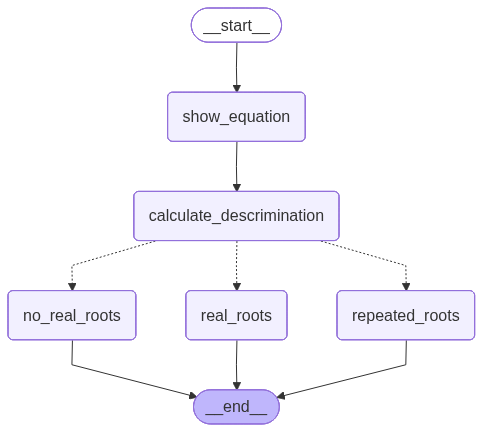

In [29]:
graph = StateGraph(QuadState)

# add node
graph.add_node("show_equation", show_equation)
graph.add_node("calculate_descrimination", calculate_descrimination)
graph.add_node("real_roots", real_roots)
graph.add_node("repeated_roots", repeated_roots)
graph.add_node("no_real_roots", no_real_roots)

# edge
graph.add_edge(START,"show_equation")
graph.add_edge("show_equation","calculate_descrimination")

graph.add_conditional_edges("calculate_descrimination",check_condition)

graph.add_edge("real_roots", END)
graph.add_edge("repeated_roots", END)
graph.add_edge("no_real_roots", END)

workflow = graph.compile()
workflow

In [ ]:
initial_state = {"a": 2, "b": -4, "c": 2}

workflow.invoke(initial_state)

{'a': 2,
 'b': -4,
 'c': 2,
 'equation': '2x2 + (-4x) + (2)',
 'descrimination': 0,
 'result': 'Only repeating root is 1.0'}